 Anthropic Economic Index — Exploratory Data Analysis

**Dataset:** Anthropic's Economic Index (Claude.ai usage data, June 2026)
**Source:** Hugging Face — Anthropic/EconomicIndex
**Size:** 1,636,573 rows × 10 columns
**Scope:** This notebook focuses on global-level analysis
as a first step into this multi-dimensional dataset.

**Key questions explored:**
- What categories of tasks do people use Claude for?
- Which tasks have the highest global usage percentage?
- Which occupations use Claude most for professional work?

## ---- Importing libraries ----

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

Done


,date_start,date_end,geo_id,geo_level,category_name,hierarchy_level,metric_id,value,node_name,node_external_id
0,2026-05-01,2026-06-01,ZA-WC,subregion,onet,2,pct,0.25,"Prepare financial documents, reports, or budgets.",4.A.3.b.6.I01
1,2026-05-01,2026-06-01,ZA-WC,subregion,onet,0,pct,0.40,Locate unusual or unique information in respon...,22420
2,2026-05-01,2026-06-01,ZA-WC,subregion,onet,0,pct,0.68,"Answer customers' questions, and provide infor...",2408
3,2026-05-01,2026-06-01,ZA-KZN,subregion,onet,1,pct,0.94,Advise others on business or operational matters.,4.A.4.b.6.I05.D10
4,2026-05-01,2026-06-01,ZA-KZN,subregion,onet,1,pct,2.18,Tutor students who need extra assistance.,4.A.4.b.3.I02.D10


 ## ---- Importing data ----

In [ ]:
claude_index=pd.read_csv(r"C:\Users\SHADAB SHAH\OneDrive\Documents\aei_claude_ai_2026-06-26.csv")
# Creating a copy of the orginal datafrane to avoid changes 
# and mistakes in it and canbe accesed if somethign goes wrong during EDA.
df=claude_index.copy()
# Converting the data columns into date-time 
df["date_start"]=pd.to_datetime(df["date_start"])
df["date_end"]=pd.to_datetime(df["date_end"])
print("Done")
df.head()

## ---- Inspecting data ----

In [3]:
# date_start to date_end: The time period in which this data is recorded
# geo_id : Name of the global countary , region , subregion.
# geo_level : The geographical area from where the data is recorded.
# category_name : Categorised task on business , job , user request and overall use (categorization by Anthrophic)
# heirarchy_level : The level of task.
# metric_id : % of usage spent doing that task.
# node_name : The actual task.
# node_external_id : The unique id assigned to each task.

In [4]:
df.info()
print('Done')
'''
 #   Column               Dtype         
---  ------            --------------            
 0   date_start        1  datetime64[ns]
 1   date_end            datetime64[ns]
 2   geo_id              object        
 3   geo_level           object        
 4   category_name       object        
 5   hierarchy_level     int64         
 6   metric_id           object        
 7   value               float64       
 8   node_name           object        
 9   node_external_id    object        
'''

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636573 entries, 0 to 1636572
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   date_start        1636573 non-null  datetime64[ns]
 1   date_end          1636573 non-null  datetime64[ns]
 2   geo_id            1636573 non-null  object        
 3   geo_level         1636573 non-null  object        
 4   category_name     1636573 non-null  object        
 5   hierarchy_level   1636573 non-null  int64         
 6   metric_id         1636573 non-null  object        
 7   value             1636573 non-null  float64       
 8   node_name         1636573 non-null  object        
 9   node_external_id  1636573 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(6)
memory usage: 124.9+ MB
Done


'\n #   Column               Dtype         \n---  ------            --------------            \n 0   date_start        1  datetime64[ns]\n 1   date_end            datetime64[ns]\n 2   geo_id              object        \n 3   geo_level           object        \n 4   category_name       object        \n 5   hierarchy_level     int64         \n 6   metric_id           object        \n 7   value               float64       \n 8   node_name           object        \n 9   node_external_id    object        \n'

In [5]:
# Checking unique values
df.nunique()

date_start              2
date_end                2
geo_id                774
geo_level               3
category_name           4
hierarchy_level         4
metric_id              53
value               10182
node_name            5784
node_external_id     5810
dtype: int64

In [6]:
pd.set_option('display.float_format',lambda x: '%.2f' % x)
# It takes the float value and tell pandas to round upto only two decimal point rather than showing scientific notation.
df.describe(include=['int64','float64'])
# The data has more than 1 million 6 hudred 36 thousand 5 hundred 73 records.
# highest value = 199.11 and lowest value  = 0.00.
# mean value = 17.59.
# The maximum value column exceed 100%, maybe bcz one execute different level task and that exceeds the percentage level

,hierarchy_level,value
count,1636573.00,1636573.00
mean,0.91,8.23
std,1.06,17.59
min,0.00,0.00
25%,0.00,0.08
50%,1.00,0.85
75%,2.00,5.93
max,3.00,199.11


In [7]:
# Checking the data of category_name
df['category_name'].unique()
# ['onet', 'overall', 'request', 'soc_occupation']
# The category of task done by using claude

array(['onet', 'overall', 'request', 'soc_occupation'], dtype=object)

# Anthropic Economic Index — Exploratory Data Analysis

In [9]:
# Filtering out the data that falls under onet category
df_onet_node=df[df['category_name']=='onet']
df_onet_node.head(20)
df_onet_node['node_name'].nunique()
df_onet_node['node_name'].count()
# 744544  tasks are fall under onet category and 3846 are unique.
# Onet generally have task like writting information material, tutoring , business advising , 
# teaching material and other business/corporation/industry/company tasks.

np.int64(744544)

In [10]:
# Filtering out the data that falls under the request category
df_req_node=df[df['category_name']=='request']
df_req_node.tail(20)
df_req_node['node_name'].nunique()
df_req_node['node_name'].count()
# 465202 tasks fall under request category with 1197 unique categories.
# These are genrally personal related tasks like emotional support , event management, advises etc.
# The general tasks an employee , student, teacher , manager utilizes claude for their daily tasks and workflow.
# They genarlly fall under category of level 0 or 1

np.int64(465202)

In [11]:
# Filtering out the data that falls under the soc_occupation category
df_soc_node=df[df['category_name']=='soc_occupation']
df_soc_node.head(20)
df_soc_node.tail(20)
df_soc_node['node_name'].nunique()
df_soc_node['node_name'].count()
# These are the specific assigned , detailed task used in business , research , medical , computers , electronics , teachers, architecture , sports etc
# almost like job/research/study related specific tasks.
# The level of these tasks fall mostly under 0 level
# There are 353817 tasks fall under this category with 740 unique tasks

np.int64(353817)

In [12]:
# Filtering out the data that falls under the overall category.
# This category is for the users that uses claude for overall everything.
df_all_node=df[df['category_name']=='overall']
df_all_node.head(40)
df_all_node.tail(20)
df_all_node['node_name'].nunique()
df_all_node['node_name'].count()
# These all are also 0 level tasks but used for broader task categories like- debugging , analysis , coding , web / app development, ai, study , databse
# usecase , learning , teaching , reports etc.
# There are 73010 tasks in this category with 1 unique category i.e., use case.

np.int64(73010)

## ---- Checking the pct metric id by filtering it and finding insights in that filtered pct data ----

In [14]:
df_pct=df[df['metric_id']=='pct']
pct_of=pd.pivot_table(df_pct,index='category_name',columns='hierarchy_level',values='value',aggfunc='mean')
pct_of

hierarchy_level,0,1,2,3
category_name,,,,
onet,0.40,0.97,2.05,6.33
request,0.43,1.21,6.60,NaN
soc_occupation,0.69,6.50,NaN,NaN


In [15]:
# onet use claude at all specified levels,mostly used at level 2 and least at 0 bcz its a department ,business like related tasks
# Reqquests are generally high at level 2 and low usage at level 1,and not any at level 3,personal requests etc
# soc_occupation usage of claude is only at two levels 0 and 1.

## ---- In pct related data checking out the data whose pct value is zero ,less than 100 %  and greater than 100 % ----

In [52]:
personal_use_chat=df_pct[df_pct['value']==0]
personal_use_chat.head(10)
# I noticed that where the pct is 0 , the task is related to sensistive and 
# persoanl information so I filter out that data.

,date_start,date_end,geo_id,geo_level,category_name,hierarchy_level,metric_id,value,node_name,node_external_id
220,2026-05-01,2026-06-01,ZA-GP,subregion,soc_occupation,0,pct,0.00,"Computer Science Teachers, Postsecondary",25-1021.00
835,2026-04-01,2026-05-01,GLOBAL,global,onet,0,pct,0.00,Assist in determining document management poli...,16234
936,2026-04-01,2026-05-01,GLOBAL,global,onet,0,pct,0.00,"Bake, roast, broil, and steam meats, fish, veg...",2176
960,2026-04-01,2026-05-01,GLOBAL,global,onet,1,pct,0.00,Design healthcare-related software applications.,4.A.2.b.2.I02.D11
977,2026-04-01,2026-05-01,GLOBAL,global,onet,0,pct,0.00,Provide feedback to design engineers on custom...,1418
1071,2026-04-01,2026-05-01,GLOBAL,global,onet,0,pct,0.00,Conduct research in a particular field of know...,20076
1079,2026-04-01,2026-05-01,GLOBAL,global,onet,0,pct,0.00,Guide or counsel students with adjustment prob...,22369
1105,2026-04-01,2026-05-01,GLOBAL,global,onet,0,pct,0.00,Negotiate details of contracts and payments.,20268
1286,2026-04-01,2026-05-01,GLOBAL,global,onet,0,pct,0.00,Confer with customers to determine the nature ...,11740
1389,2026-04-01,2026-05-01,GLOBAL,global,onet,0,pct,0.00,Review and update standard operating procedure...,15415


In [18]:
# Now lets check ehat the data is about for pct value > 100 or = 100
df_pct[df_pct['value']>=100].head(10)
# The pct is clean , there is no data correspond to 100%

,date_start,date_end,geo_id,geo_level,category_name,hierarchy_level,metric_id,value,node_name,node_external_id


In [19]:
# Checking the data that has < 100
pct_lesser_100=df_pct[df_pct['value']<=100]
pct_lesser_100.nlargest(20, 'value')
# The highest value of pct is 47.60 
# And this percaentage is mostly in  tasks for content creation, copywritting, education, learning and teaching

,date_start,date_end,geo_id,geo_level,category_name,hierarchy_level,metric_id,value,node_name,node_external_id
1396609,2026-04-01,2026-05-01,GH-AH,subregion,request,2,pct,47.60,Education & Learning,4bba0afb-b918-5e01-b26e-fa2da661c5f9
1337612,2026-04-01,2026-05-01,PE-LAL,subregion,request,2,pct,41.32,Education & Learning,4bba0afb-b918-5e01-b26e-fa2da661c5f9
1514922,2026-05-01,2026-06-01,NG-AN,subregion,request,2,pct,39.95,Content Creation & Copywriting,1435fa0e-a9fb-52e5-ba5c-ca24b76d4591
1061197,2026-05-01,2026-06-01,PE-PIU,subregion,request,2,pct,39.92,Education & Learning,4bba0afb-b918-5e01-b26e-fa2da661c5f9
1614208,2026-05-01,2026-06-01,NG-LA,subregion,request,2,pct,39.18,Content Creation & Copywriting,1435fa0e-a9fb-52e5-ba5c-ca24b76d4591
1377278,2026-05-01,2026-06-01,NGA,country,request,2,pct,38.63,Content Creation & Copywriting,1435fa0e-a9fb-52e5-ba5c-ca24b76d4591
1582126,2026-05-01,2026-06-01,NG-FC,subregion,request,2,pct,38.49,Content Creation & Copywriting,1435fa0e-a9fb-52e5-ba5c-ca24b76d4591
1208848,2026-05-01,2026-06-01,ZA-EC,subregion,request,2,pct,38.44,Education & Learning,4bba0afb-b918-5e01-b26e-fa2da661c5f9
778868,2026-04-01,2026-05-01,NGA,country,request,2,pct,38.21,Content Creation & Copywriting,1435fa0e-a9fb-52e5-ba5c-ca24b76d4591
1590846,2026-04-01,2026-05-01,NG-LA,subregion,request,2,pct,38.18,Content Creation & Copywriting,1435fa0e-a9fb-52e5-ba5c-ca24b76d4591


## ---- AS A BEGINNER I WILL FOCUS ON GLOBAL LEVEL DATA NOW ----

In [53]:
df['geo_level'].unique()

array(['subregion', 'country', 'global'], dtype=object)

## Filtering and inspecting global data

In [22]:
df_global=df[df['geo_level']=='global']
df_global.head(10)

,date_start,date_end,geo_id,geo_level,category_name,hierarchy_level,metric_id,value,node_name,node_external_id
809,2026-04-01,2026-05-01,GLOBAL,global,onet,0,artifact_script_or_snippet_pct,0.00,"Write speeches, press releases, or other promo...",18924
810,2026-04-01,2026-05-01,GLOBAL,global,onet,0,multitasking_pct,40.42,"Write speeches, press releases, or other promo...",18924
811,2026-04-01,2026-05-01,GLOBAL,global,onet,0,artifact_plan_or_strategy_pct,0.18,"Write speeches, press releases, or other promo...",18924
812,2026-04-01,2026-05-01,GLOBAL,global,onet,0,human_only_ability_pct,94.73,"Write speeches, press releases, or other promo...",18924
813,2026-04-01,2026-05-01,GLOBAL,global,onet,0,artifact_audio_or_music_pct,0.00,"Write speeches, press releases, or other promo...",18924
814,2026-04-01,2026-05-01,GLOBAL,global,onet,0,artifact_game_or_interactive_pct,0.00,"Write speeches, press releases, or other promo...",18924
815,2026-04-01,2026-05-01,GLOBAL,global,onet,0,use_case_work_pct,81.72,"Write speeches, press releases, or other promo...",18924
816,2026-04-01,2026-05-01,GLOBAL,global,onet,0,collaboration_none_pct,0.53,"Write speeches, press releases, or other promo...",18924
817,2026-04-01,2026-05-01,GLOBAL,global,onet,0,artifact_analysis_or_summary_pct,0.70,"Write speeches, press releases, or other promo...",18924
818,2026-04-01,2026-05-01,GLOBAL,global,onet,3,artifact_script_or_snippet_pct,0.91,Handling and Moving Objects,4.A.3.a.2


In [23]:
# Checking metric id to see what pct of claude is used to execute which task
df_global['metric_id'].unique()

array(['artifact_script_or_snippet_pct', 'multitasking_pct',
       'artifact_plan_or_strategy_pct', 'human_only_ability_pct',
       'artifact_audio_or_music_pct', 'artifact_game_or_interactive_pct',
       'use_case_work_pct', 'collaboration_none_pct',
       'artifact_analysis_or_summary_pct',
       'artifact_email_or_message_pct', 'collaboration_validation_pct',
       'artifact_academic_paper_or_thesis_pct',
       'collaboration_bucket_automation_pct',
       'artifact_marketing_or_social_content_pct',
       'artifact_document_or_report_pct',
       'artifact_explanation_or_answer_pct',
       'artifact_presentation_or_slides_pct',
       'collaboration_directive_pct', 'use_case_coursework_pct',
       'artifact_none_pct', 'artifact_chart_or_visualization_pct',
       'artifact_educational_material_pct', 'pct',
       'collaboration_task_iteration_pct',
       'artifact_code_fix_or_debug_pct', 'artifact_app_or_website_pct',
       'artifact_ml_or_ai_system_pct', 'ai_education_y

In [24]:
# Lets first look upto pct average value for all categories .
global_pct=df_global[df_global['metric_id']=='pct']
global_pct.groupby('category_name')['value'].mean()
# onet has 0.11 average pct value.=,it points to the job occupations .
# request has 0.26 pct avg value, it the users requests .
# soc_occupation has 0.26 pct avg  value
# The soc_occupation have highest pct  avg value , soc_occupation contains the job fields tasks data

category_name
onet             0.11
request          0.24
soc_occupation   0.26
Name: value, dtype: float64

In [25]:
global_pct.groupby(['category_name','hierarchy_level'])['value'].mean()
# Globally, Onet users  used claude at level 3 mostly with average of 2.76.
# Users general requests fall under level 2 globally with average of 4.83.
# soc_occupation category users use claude for level 1 task globally with average of 4.39.

category_name   hierarchy_level
onet            0                 0.04
                1                 0.14
                2                 0.47
                3                 2.76
request         0                 0.10
                1                 0.50
                2                 4.83
soc_occupation  0                 0.14
                1                 4.39
Name: value, dtype: float64

## ---- Plotting a bar graph showing the comparison of categories at different hierarchy level with pct avg values worldwide ----

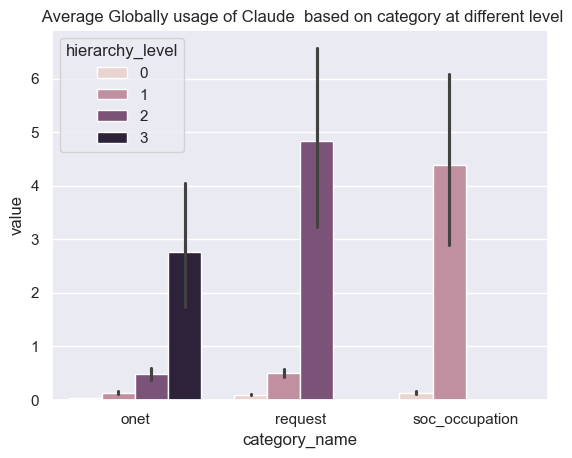

In [27]:
sns.barplot(data=global_pct,x='category_name',y='value',hue='hierarchy_level')
plt.title(" Average Globally usage of Claude  based on category at different level")
plt.show()

In [28]:
# Think of hierarchy levels as in a analogy as:
# 3 = Broadest task, grouping of tasks.
# 2 = Category of tasks.
# 1 =  Sub categories.
# 0 = exact specific tasks.

# The bar graph showed visually what I found out in cell 102

## ---- Filtering data of human only related tasks from globally data ----

In [30]:
human_ability=df_global[df_global['metric_id']=='human_only_ability_pct']

In [31]:
# Inspecting human ability task on global level.
human_ability.head(20)
df.tail(10)
# Planning , startegy , personal use, guide, surverys , research and other tasks like this 

,date_start,date_end,geo_id,geo_level,category_name,hierarchy_level,metric_id,value,node_name,node_external_id
1636563,2026-05-01,2026-06-01,GLOBAL,global,soc_occupation,0,use_case_work_pct,18.67,Furniture Finishers,51-7021.00
1636564,2026-05-01,2026-06-01,GLOBAL,global,soc_occupation,0,use_case_work_pct,21.00,Coaches and Scouts,27-2022.00
1636565,2026-05-01,2026-06-01,GLOBAL,global,request,1,use_case_work_pct,7.07,Medical Questions,c1e4059f-3e6d-5507-8bf3-a5eaac616ed5
1636566,2026-05-01,2026-06-01,GLOBAL,global,request,1,use_case_work_pct,17.32,Certification and training,1f9f350d-bf70-5b29-bd37-9395f89febf4
1636567,2026-05-01,2026-06-01,GLOBAL,global,soc_occupation,0,use_case_work_pct,57.63,Textile Bleaching and Dyeing Machine Operators...,51-6061.00
1636568,2026-05-01,2026-06-01,GLOBAL,global,soc_occupation,0,use_case_work_pct,17.81,"Locker Room, Coatroom, and Dressing Room Atten...",39-3093.00
1636569,2026-05-01,2026-06-01,GLOBAL,global,soc_occupation,1,use_case_work_pct,38.35,"Life, Physical, and Social Science",19
1636570,2026-05-01,2026-06-01,GLOBAL,global,soc_occupation,0,use_case_work_pct,81.25,Gambling Change Persons and Booth Cashiers,41-2012.00
1636571,2026-05-01,2026-06-01,GLOBAL,global,soc_occupation,0,use_case_work_pct,29.53,Police and Sheriff's Patrol Officers,33-3051.00
1636572,2026-05-01,2026-06-01,GLOBAL,global,soc_occupation,0,use_case_work_pct,42.60,Remote Sensing Technicians,19-4099.03


In [32]:
# Onet uses claude for human ability tasks at all levels.
# Claude users requests level 0,1,2 tasks. 
# soc_occupation utilizes claude for level 2  and 1 tasks.
# overall the human ability tasks are at level 0

In [33]:
# Checking the top 10 task's pct value globally
task_10=global_pct.groupby('node_name')['value'].mean().sort_values(ascending=False).head(10)
task_10

node_name
Computer and Mathematical                                 23.88
Providing Consultation and Advice to Others               23.34
Content Creation & Copywriting                            22.16
Arts, Design, Entertainment, Sports, and Media            13.27
Education & Learning                                      12.88
Getting Information                                       12.50
Educational Instruction and Library                       12.34
Software Development                                      11.82
Thinking Creatively                                       11.70
Gather information from physical or electronic sources.   11.58
Name: value, dtype: float64

## ---- Plotting the globally top 10 tasks requested from claude ----

In [ ]:
sns.barplot(x=task_10.values,y=task_10.index)
plt.title("Top 10 Most Used Tasks Globally")
plt.show()

In [36]:
# Computational and Mathematical tasks stands ate the top.
# Second one is Providing Consultation and Advice to Others.
# Content Creation & Copywriting.

## ---- Checking how the categories varies over time globally ----

In [38]:
time_trend = global_pct.groupby(['date_start','category_name'])['value'].mean().reset_index()
time_trend

,date_start,category_name,value
0,2026-04-01,onet,0.11
1,2026-04-01,request,0.23
2,2026-04-01,soc_occupation,0.26
3,2026-05-01,onet,0.11
4,2026-05-01,request,0.24
5,2026-05-01,soc_occupation,0.27


## ---- Representimg the trend of categories ----

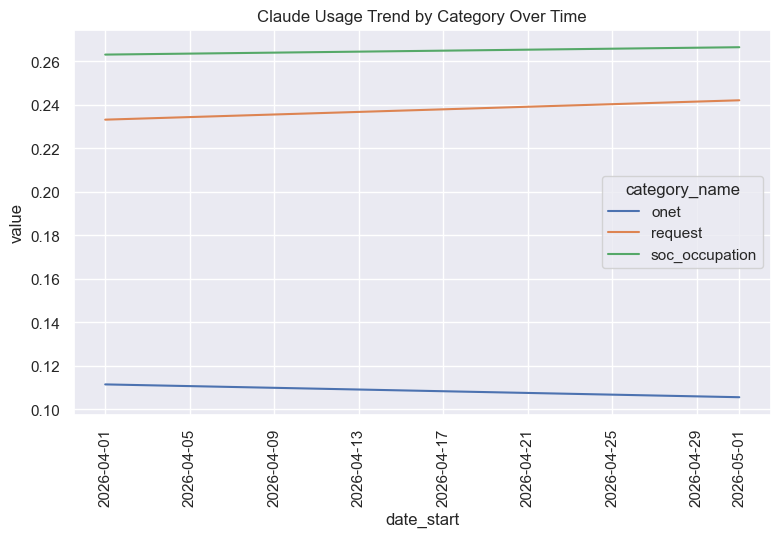

In [40]:
plt.figure(figsize=(9,5))
sns.lineplot(data=time_trend,x='date_start',y='value',hue='category_name')
plt.xticks(rotation=90)
plt.title("Claude Usage Trend by Category Over Time")
plt.show()

In [41]:
# soc_occupation and requests usage of claude does increase in 2 months from 2026-04-01 to 2026-05-01
# The claude usage of onet sligltly decreassed from  2026-04-01 to 2026-05-01

## ---- Now lets look at the top soc_occupation use case tasks pct ----

In [43]:
use_case=df_global[(df_global['metric_id']=='use_case_work_pct') 
    & (df_global['category_name']=='soc_occupation')]
top_occ=(use_case.sort_values('value',ascending=False).head(10)[['node_name','value']])
top_occ

,node_name,value
761119,"Service Unit Operators, Oil and Gas",100.00
1561804,"Service Unit Operators, Oil and Gas",100.00
584018,Electrical Power-Line Installers and Repairers,96.30
531180,Labor Relations Specialists,95.83
1625912,Labor Relations Specialists,94.27
1560871,Adapted Physical Education Specialists,92.46
831542,Fast Food and Counter Workers,92.01
1636420,Precision Agriculture Technicians,90.91
257823,First-Line Supervisors of Passenger Attendants,90.61
1610198,Medical and Health Services Managers,90.43


 ---- Visually comparing the top 10 most soc_occupation tasks at use case pct ----

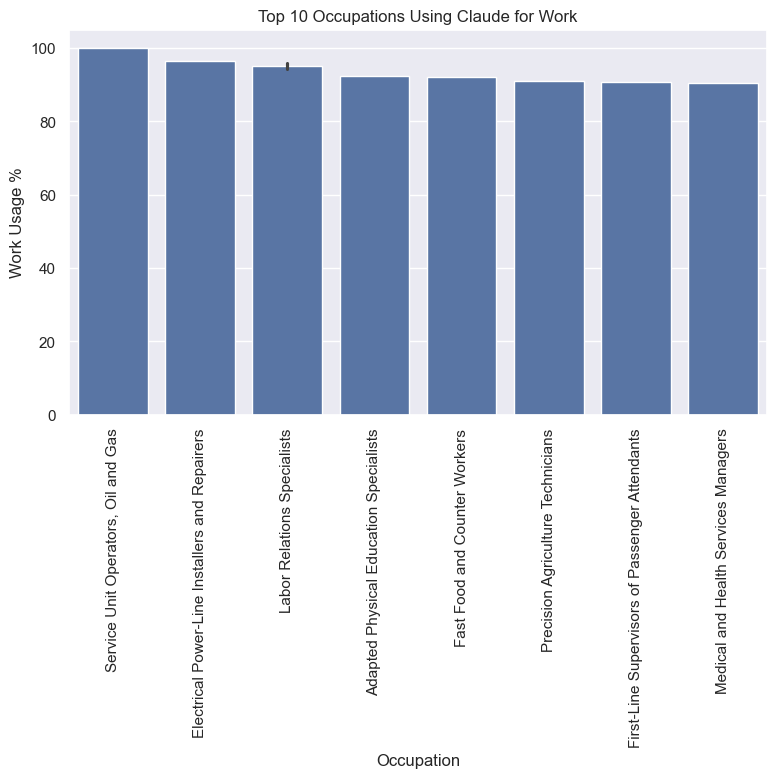

In [51]:
plt.figure(figsize=(9,5))
sns.barplot(data=top_occ,x='node_name',y='value')
plt.xticks(rotation=90)
plt.title("Top 10 Occupations Using Claude for Work")
plt.xlabel("Occupation")
plt.ylabel("Work Usage %")
plt.show()

In [54]:
# Service Unit Operators, Oil and Gas tasks uses claude is at top with use case pct = 100.
# Electrical Power-Line Installers and Repairers is at second qith use case pct = 96
# Labor Relations Specialists have use case pct value = approx 94 .
# Adapted Physical Education Specialists and Fast Food and Counter Workers have approx same use case pct value=92%.
# While the others corresponding use case pct value is same i.e.,90 approx.